In [ ]:
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
!pip install holidays
import holidays
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
import math

from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

# Introdução

Nesse colab, utilizaremos o modelo preditivo para calcular o tempo de ciclo de cada linha em cada horário e, com ele, estabelecermos a quantidade mínima de Ônibus em operação para que o intervalo de saída dos ônibus seja respeitado.

Como referência para os cálculos, utilizei o material de Engenharia de Tráfego e Planejamento de Operação da UNESP, presentes na página da professora Barbara Stolte Bezerra. O pdf pode ser encontrado [aqui](https://pessoas.feb.unesp.br/barbara/files/2013/08/DIMENSIONAMENTO_FROTA.pdf).

Nosso objetivo prever a quantidade de ônibus em uma linha que serão necessários para cumprir o intervalo de partida (`headway_secs`), definido pela prefeitura. Para isso, utilizaremos o modelo treinado para prever a duração do Tempo de Ciclo de uma linha de ônibus em um determinada data e horário.

# Tempo de Ciclo
Segundo material da UNESP, O tempo de ciclo (T) de uma linha de ônibus é dado pelo tempo total gasto para realizar uma viagem redonda (ida e volta), incluindo o tempo parado nos terminais.

Esse tempo pode ser dado pela equação abaixo:
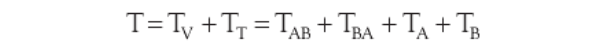

Sendo:
- T = Tempo de Ciclo
- $T_{AB}$ = tempo de percurso do terminal A até o terminal B
- $T_{BA}$ = tempo de percurso do terminal B até o terminal A
- $T_A$ = Tempo parado no terminal A
- $T_B$ = Tempo parado no terminal B

Com o nosso modelo, podemos prever a duração da viagem entre os terminais. Porém, não temos dados sobre o tempo que os ônibus ficam parados nos terminais. Por esse motivo, iremos considerar um tempo fixo (ex: 10 minutos) para uma análise inicial.

Entretanto, iremos precisar cruzar a hora da viagem com o

Portanto, utilizando o nosso modelo, podemos realizar o seguinte algoritomo para calcular o tempo de ciclo:

Entrada(t_inicial (hora da viagem), demais informacoes)

1. t_inicial = t
1. Calculamos a previsão (h) para duração da viagem de ida dado o tempo t e demais informacoes
2. t += h
3. t += T_b (10min)
4. Calculamos a previsão (h) para duração da viagem de volta dado o tempo t e demais informações
3. t += T_a (10 min)
4. T (tempo de ciclo) =

## Pontos de atenção
Tivemos que chutar um tempo para pausa nos terminais (10 minutos) pois não conseguimos encontrar esses dados. Mas uma análise futura pode ser adequada para investigar a tabela de viagens e tentar encontrar uma média desses valores, calculando o tempo entre as viagens

O `headway_secs` muda conforme a direção.

In [ ]:
# carrega o modelo na memória RAM, label encoder e tabelas csv necessarias
caminho_modelo = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/modeloML/modelo.pkl"
modelo = joblib.load(caminho_modelo)
le_linha = joblib.load('/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/modeloML/le_linha.pkl')
df_headways = pd.read_csv("/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados tratados/headways_por_linhas.csv")

In [ ]:
#Note viagem deve ser um tupla com dados de uma viagem futura para ser calculado o tempo de ciclo
def tempo_ciclo(viagem_ponteiro, pausa_terminal):
  viagem = viagem_ponteiro.copy() #apenas para nao modificar os valores de entrada

  #precisamos converter a string da linha para o valor numerico via label encoder criado em Treinamento do Modelo  PS.2026 Grupo L
  linha_str = str(viagem['servico'].values[0])
  viagem['servico'] = le_linha.transform([linha_str])[0]

  #prevendo a hora chegada no ponto final
  t_inicial = viagem['hora_partida'].values[0]
  t = t_inicial + modelo.predict(viagem)[0]

  #somando pausa no terminal com previsao da volta
  t += pausa_terminal
  viagem['hora_partida'] = t % 1440
  viagem['sentido'] = 1 - viagem['sentido'].values[0] #inverte o sentido para viagem de volta
  t += modelo.predict(viagem)[0]
  t += pausa_terminal #tempo que o onibus vai ficar parado novamente no terminal inicial

  t_ciclo = t - t_inicial

  return t_ciclo

def filtrar_regras_headway(viagem_ponteiro, df_headways):
  viagem = viagem_ponteiro.copy()

  #extraindo dados da viagem
  linha_atual = str(viagem['servico'].values[0])
  hora_atual = viagem['hora_partida'].values[0]
  dia_semana_num = int(viagem['dia_semana'].values[0])

  # traduzindo o dia da semana pra coluna do gtfs
  mapa_dias = {0: 'monday', 1: 'tuesday', 2: 'wednesday', 3: 'thursday', 4: 'friday', 5: 'saturday', 6: 'sunday'}
  coluna_dia = mapa_dias[dia_semana_num]

  #filtrando para encontrar a regra que se encaixa para essa predição de viagem
  df_filtrado = df_headways[
      (df_headways['trip_short_name'] == linha_atual) &
      (df_headways[coluna_dia] == 1)
  ]

  hora_virtual = hora_atual + 1440 # Garante leitura de GTFS com 25h+

  regra_normal = (df_filtrado['start_time'] <= hora_atual) & (hora_atual < df_filtrado['end_time'])
  regra_madrugada = (df_filtrado['start_time'] > df_filtrado['end_time']) & ((hora_atual >= df_filtrado['start_time']) | (hora_atual < df_filtrado['end_time']))
  regra_gtfs_24h = (df_filtrado['start_time'] <= hora_virtual) & (hora_virtual < df_filtrado['end_time'])

  # A regra ativará se o horário cair em QUALQUER um dos 3 cenários
  regra = df_filtrado[regra_normal | regra_madrugada | regra_gtfs_24h]

  # Se a prefeitura não exige ônibus nesse horário
  if regra.empty:
      return 0

 # 1. Ordena a tabela pela data de término (end_date) da mais futura para a mais antiga
  regra = regra.sort_values(by='end_date', ascending=False)

  # 2. Pega a primeira regra de CADA sentido (Ida e Volta), descartando as versões velhas
  regra = regra.drop_duplicates(subset=['direction_id'], keep='first')

  # 3. Passando intervalo de segundos para minutos do gargalo
  headway_min = regra['headway_secs'].min() / 60.0

  return headway_min


def dimensionamento_frota(viagem_ponteiro, df_headways):
  viagem = viagem_ponteiro.copy() #apenas para nao modificar os valores de entrada

  #calculo tempo de ciclo nessa hora via modelo preditivo
  ciclo_total = tempo_ciclo(viagem, 10)

  # Calcula qual é o intervalo exigido pela prefeitura
  headway = filtrar_regras_headway(viagem, df_headways)

  #proteção contra divisão por zero
  if headway == 0:
      return 0

  frota = ciclo_total / headway

  return frota

def gera_df_viagem(servico, sentido, mes, dia, hora_partida, ano):
  data_alvo = date(int(ano), int(mes), int(dia))
  dia_semana = data_alvo.weekday()

  # checa se é feriado
  feriados_rj = holidays.Brazil(state='RJ')
  eh_feriado = 1 if data_alvo in feriados_rj else 0
  viagem = {
        'servico': [servico],
        'sentido': [sentido],
        'mes_viagem': [mes],
        'dia_viagem': [dia],
        'hora_partida': [hora_partida],
        'dia_semana': [dia_semana],
        'eh_feriado': [eh_feriado],
    }

  return pd.DataFrame(viagem)


viagem = gera_df_viagem("324", 0, 5, 7, 19*60, 2026)

display(viagem.head())
print(tempo_ciclo(viagem, 10))
print(dimensionamento_frota(viagem, df_headways))





# Dimensionamento diário da frota

Dado um dia qualquer e uma linha de ônibus, criaremos um gráfico que mostra o dimensionamento diário da frota, indicando quantos ônibus essa frota deve ter de 10 em 10 minutos. Para isso, utilizaremos as funções acima, utilizando o modelo preditivo treinado anteriormente.

In [ ]:
def plot_dimensionamento_diario(linha, sentido, dia, mes, ano, df_headways, passo=30):
    #gera gráfico de quantidade de onibus por linha em um dia

    minutos_do_dia = list(range(0, 1440, passo))
    horas_decimais = [m / 60.0 for m in minutos_do_dia] # Converte para hora (ex: 90 min = 1.5 h)
    frota_necessaria = []

    # variaveis para rastrear mudanças no headway
    mudancas_headway = []
    headway_anterior = None

    for minuto in minutos_do_dia:

        viagem_instante = gera_df_viagem(linha, sentido, mes, dia, minuto, ano)
        qtd_onibus = dimensionamento_frota(viagem_instante, df_headways)
        # 2. Arredonda forçadamente para CIMA (Teto)
        qtd_onibus= math.ceil(qtd_onibus)

        frota_necessaria.append(qtd_onibus)

        #rastreando mudanças
        headway_atual = filtrar_regras_headway(viagem_instante, df_headways)

        # Se for diferente do anterior (e não for o primeiro loop), nós ANOTAMOS a mudança!
        if headway_anterior is not None and headway_atual != headway_anterior:
            hora_mudanca = minuto / 60.0
            mudancas_headway.append((hora_mudanca, headway_atual))

        headway_anterior = headway_atual

    # criando grafico
    plt.figure(figsize=(14, 6))
    sns.set_style("whitegrid")

    # Plotando a linha principal em degraus (Step Chart)
    plt.step(horas_decimais, frota_necessaria, color='#2c3e50', linewidth=2.5, where='post', label=f'Frota Sugerida - Linha {linha}')
    plt.fill_between(horas_decimais, frota_necessaria, color='#3498db', alpha=0.3, step='post')

    # --- DESENHANDO AS LINHAS VERTICAIS DE MUDANÇA DE REGRA ---
    for hora, novo_headway in mudancas_headway:
        # Linha vertical pontilhada vermelha
        plt.axvline(x=hora, color='#e74c3c', linestyle='--', linewidth=0.5, alpha=0.8)

        # Escrevendo o texto ao lado da linha
        plt.text(hora + 0.15, max(frota_necessaria) * 0.85,
                 f'{int(novo_headway)} min',
                 color='#e74c3c', fontsize=6, fontweight='bold', rotation=90)

    # Configurando os detalhes do gráfico
    plt.title(f'Dimensionamento Dinâmico de Frota - Linha {linha} ({dia}/{mes}/{ano})', fontsize=16, fontweight='bold')
    plt.xlabel('Hora do Dia (0h às 24h)', fontsize=12)
    plt.ylabel('Número de Ônibus Necessários', fontsize=12)

    # Eixo X (passo em passo hora)
    plt.xticks(range(0, 25, 2))
    plt.xlim(0, 24)

    # Eixo Y (5 em 5 ônibus) - Adapta a altura ao máximo de ônibus + uma margem
    altura_maxima = max(frota_necessaria) if max(frota_necessaria) > 0 else 10
    topo_y = int(altura_maxima * 1.15) + 1
    plt.ylim(0, topo_y)
    plt.yticks(range(0, topo_y, 5))

    # Colocando a legenda no canto superior esquerdo para não cobrir as linhas vermelhas
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

# teste
plot_dimensionamento_diario(linha="321", sentido=0, dia=12, mes=5, ano=2026, df_headways=df_headways, passo=10) #manter sempre sentido = 0